# 02 -- Feature Engineering & Leakage Analysis

Builds the Model 1 / Model 2 feature frames from `src/features.py`, and empirically demonstrates *why* certain fields are excluded as leakage (see `reports/design_decisions.md`) rather than just asserting it.

In [1]:
import sys
sys.path.insert(0, "../src")
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
con = duckdb.connect("../data/cms_medicare.duckdb", read_only=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

from features import build_model1_frame, build_model2_frame, MODEL1_TARGET
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

## Model 1 feature frame

In [2]:
m1 = build_model1_frame(con)
m1.describe(include='all').T

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rendering_npi,6687621,1548060,1174520795,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_year,"6,687,621.00",NaN,NaN,NaN,"2,020.56",1.71,"2,018.00","2,019.00","2,021.00","2,022.00","2,023.00"
provider_specialty,6687621,104,Nurse Practitioner,872417,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_state,6687621,63,CA,525448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_entity_type,6687621,2,Individual,6318253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_medicare_participating,6687621,2,True,6680381,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_ruca_code,"6,681,576.00",NaN,NaN,NaN,1.63,3.43,1.00,1.00,1.00,1.00,99.00
distinct_hcpcs_codes,"6,687,621.00",NaN,NaN,NaN,8.49,10.63,1.00,3.00,5.00,10.00,658.00
service_line_count,"6,687,621.00",NaN,NaN,NaN,8.80,11.37,1.00,3.00,5.00,10.00,658.00
provider_total_medicare_payment,"6,687,621.00",NaN,NaN,NaN,"79,304.23","632,319.89",0.04,"8,472.30","25,670.47","67,248.34","299,319,622.61"


## Leakage demonstration: what happens if we DON'T exclude near-identity features?

`design_decisions.md` argues `provider_total_services` and `payment_per_beneficiary`-type fields are algebraically close to the target (`payment ~= services x avg_payment_per_service`) and must be excluded. Here's the empirical proof: a model WITH those fields vs. WITHOUT them, same train/test split, same algorithm.

In [3]:
leak_df = con.execute("""
    SELECT provider_total_medicare_payment, provider_total_services,
           payment_per_beneficiary, payment_per_service, distinct_hcpcs_codes,
           service_line_count, provider_ruca_code
    FROM gold_provider_year
    WHERE provider_total_medicare_payment > 0 AND source_year = 2023
""").fetchdf().dropna()

y = np.log1p(leak_df["provider_total_medicare_payment"])
X_leaky = leak_df[["provider_total_services", "payment_per_beneficiary", "payment_per_service"]]
X_clean = leak_df[["distinct_hcpcs_codes", "service_line_count", "provider_ruca_code"]]

for name, X in [("WITH near-leakage features", X_leaky), ("WITHOUT (clean) features", X_clean)]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    model = HistGradientBoostingRegressor(random_state=42).fit(Xtr, ytr)
    print(f"{name}: R2 = {r2_score(yte, model.predict(Xte)):.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

WITH near-leakage features: R2 = 0.998


WITHOUT (clean) features: R2 = 0.587


The leaky feature set should score dramatically higher R² -- confirming those fields are near-restatements of the target, not genuine predictors, and validating their exclusion from the real Model 1 in `src/modeling.py`.

(This quick demo uses a random single-year 80/20 split on a small feature subset purely to illustrate the leakage gap -- it is not directly comparable to the real Model 1 in `src/modeling.py`, which uses the full feature set and a strict temporal holdout, and scores R² = 0.280.)

## Model 2 feature frame (benchmark-reliable provider-years only)

In [4]:
m2 = build_model2_frame(con)
print(m2.shape)
m2["is_high_cost_p90"].value_counts(normalize=True)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(6687176, 12)


is_high_cost_p90
0   0.90
1   0.10
Name: proportion, dtype: float64

## Correlation among Model 1's actual (non-leaky) numeric features

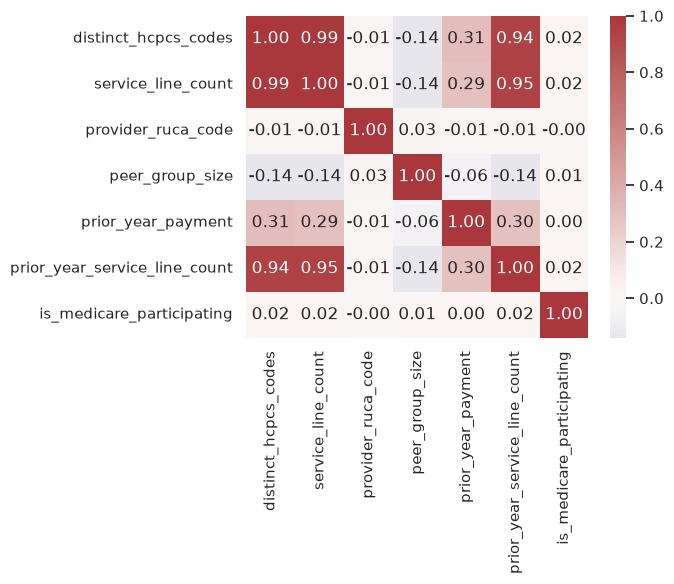

In [5]:
from features import MODEL1_NUMERIC_FEATURES
corr = m1[MODEL1_NUMERIC_FEATURES].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
plt.tight_layout(); plt.show()